# Credit Risk Modelling — Part 4.5: Random Forest
---
**Objective:** Train and evaluate a Random Forest classifier — our first ensemble tree model.

Random Forest builds hundreds of decision trees on random subsets of data and features, then averages their predictions. This makes it:
- **Robust to outliers** (the intentional noise in our data)
- **Naturally handles non-linearity** and feature interactions
- **Resistant to overfitting** due to bagging + feature subsampling
- **No feature scaling needed** — trees split on rank, not magnitude

**Steps:**
1. Load data & framework
2. Hyperparameter choices & rationale
3. Train the model
4. Cross-validation
5. All test metrics
6. Full 6-panel dashboard
7. Feature importance analysis
8. Out-of-bag (OOB) error check
9. Compare vs LR and bureau score
10. Save result

## 1 — Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, json, time, warnings
from pathlib import Path

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics         import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
GRAY = "#9E9E9E"

# Load arrays
X_train        = np.load("X_train.npy")
X_test         = np.load("X_test.npy")
y_train        = np.load("y_train.npy")
y_test         = np.load("y_test.npy")
sample_weights = np.load("sample_weights.npy")
meta           = joblib.load("preprocessing_meta.pkl")
CV             = joblib.load("cv_strategy.pkl")

with open("metric_reference.json") as f:
    metric_ref = json.load(f)

MODEL_NAME  = "Random Forest"
MODEL_COLOR = metric_ref["model_colors"][MODEL_NAME]

results     = joblib.load("results_so_far.pkl")
bureau_auc  = results["Bureau Score (score_1)"]["test_auc"]
lr_auc      = results["Logistic Regression"]["test_auc"]
bureau_proba = np.load("score1_proba_test.npy")
feature_cols = meta["feature_cols_final"]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Bureau Score AUC       : {bureau_auc:.4f}  <- must beat this")
print(f"Logistic Regression AUC: {lr_auc:.4f}  <- aim to beat this too")
print("✓ Loaded")

X_train : (28397, 198)
X_test  : (4000, 198)
Bureau Score AUC       : 0.8152  <- must beat this
Logistic Regression AUC: 0.8575  <- aim to beat this too
✓ Loaded


---
## 2 — Hyperparameter Choices & Rationale

| Parameter | Value | Why |
|---|---|---|
| `n_estimators` | `200` | More trees = more stable predictions; diminishing returns beyond 300 |
| `max_depth` | `10` | Prevents individual trees from memorising training data |
| `min_samples_leaf` | `20` | No leaf can have fewer than 20 samples — smooths noisy predictions |
| `max_features` | `"sqrt"` | Each split considers √198 ≈ 14 features — key bagging mechanism |
| `class_weight` | `"balanced_subsample"` | Reweights classes within each bootstrap sample — handles 16.3:1 imbalance |
| `oob_score` | `True` | Free out-of-bag validation — like CV but from unused bootstrap samples |
| `n_jobs` | `-1` | Use all CPU cores — trees are independent, embarrassingly parallel |
| `random_state` | `42` | Reproducibility |

> **`balanced_subsample` vs `balanced`:**  
> `balanced_subsample` recomputes class weights for each bootstrap sample independently.  
> This is better than `balanced` for Random Forest because each tree sees a different subsample.

## 3 — Train the Model

In [2]:
rf = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = 10,
    min_samples_leaf  = 20,
    max_features      = "sqrt",
    class_weight      = "balanced_subsample",
    oob_score         = True,
    n_jobs            = -1,
    random_state      = 42
)

print("Training Random Forest (200 trees, parallel)...")
t0 = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - t0

print(f"✓ Training complete in {train_time:.1f}s")
print()
print(f"n_estimators    : {rf.n_estimators}")
print(f"max_depth       : {rf.max_depth}")
print(f"min_samples_leaf: {rf.min_samples_leaf}")
print(f"max_features    : {rf.max_features}")
print(f"OOB Score (AUC proxy — see note): {rf.oob_score_:.4f}")
print()
print("Note: oob_score_ uses accuracy metric internally, not AUC.")
print("It gives a rough indication of fit quality but we use CV AUC as primary.")

Training Random Forest (200 trees, parallel)...
✓ Training complete in 9.2s

n_estimators    : 200
max_depth       : 10
min_samples_leaf: 20
max_features    : sqrt
OOB Score (AUC proxy — see note): 0.8069

Note: oob_score_ uses accuracy metric internally, not AUC.
It gives a rough indication of fit quality but we use CV AUC as primary.


---
## 4 — Cross-Validation (5-Fold Stratified)

Random Forest is slower than LR so CV takes longer — but it is essential  
to confirm the model generalises and is not memorising the training data.

In [3]:
print("Running 5-fold stratified CV (this may take a few minutes)...")
t0 = time.time()
cv_scores = cross_val_score(
    rf, X_train, y_train,
    cv      = CV,
    scoring = "roc_auc",
    n_jobs  = -1
)
cv_time = time.time() - t0

print(f"CV complete in {cv_time:.1f}s")
print()
print(f"{'Fold':<8} {'AUC':>10}")
print("-" * 20)
for i, score in enumerate(cv_scores, 1):
    print(f"  {i:<6} {score:>10.4f}")
print("-" * 20)
print(f"  {'Mean':<6} {cv_scores.mean():>10.4f}")
print(f"  {'Std':<6} {cv_scores.std():>10.4f}")

Running 5-fold stratified CV (this may take a few minutes)...
CV complete in 36.8s

Fold            AUC
--------------------
  1          0.8418
  2          0.8511
  3          0.8546
  4          0.8522
  5          0.8496
--------------------
  Mean       0.8499
  Std        0.0043


## 5 — Compute All Test Set Metrics

In [4]:
def ks_statistic(y_true, y_proba):
    df = pd.DataFrame({"y": y_true, "p": y_proba}).sort_values("p")
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    df["cum_pos"] = (df["y"] == 1).cumsum() / n_pos
    df["cum_neg"] = (df["y"] == 0).cumsum() / n_neg
    df["ks"]      = (df["cum_neg"] - df["cum_pos"]).abs()
    return df["ks"].max(), df.loc[df["ks"].idxmax(), "p"], df

proba_test  = rf.predict_proba(X_test)[:, 1]
proba_train = rf.predict_proba(X_train)[:, 1]

test_auc  = roc_auc_score(y_test, proba_test)
test_ap   = average_precision_score(y_test, proba_test)
gini      = 2 * test_auc - 1
train_auc = roc_auc_score(y_train, proba_train)
ks_val, ks_thresh, ks_df = ks_statistic(y_test, proba_test)

fpr_arr, tpr_arr, thresh_arr = roc_curve(y_test, proba_test)
j_idx      = np.argmax(tpr_arr - fpr_arr)
opt_thresh = float(thresh_arr[j_idx])
y_pred_opt = (proba_test >= opt_thresh).astype(int)

print("=" * 55)
print("  RANDOM FOREST — TEST SET RESULTS")
print("=" * 55)
print(f"  {'Metric':<35} {'Value':>12}")
print(f"  {'-'*49}")
print(f"  {'Test ROC-AUC':<35} {test_auc:>12.4f}")
print(f"  {'Train ROC-AUC (overfit check)':<35} {train_auc:>12.4f}")
print(f"  {'Test Avg Precision (AP)':<35} {test_ap:>12.4f}")
print(f"  {'Gini Coefficient':<35} {gini:>12.4f}")
print(f"  {'KS Statistic':<35} {ks_val:>12.4f}")
print(f"  {'Optimal Threshold (Youden J)':<35} {opt_thresh:>12.4f}")
print(f"  {'CV AUC (mean)':<35} {cv_scores.mean():>12.4f}")
print(f"  {'CV AUC (std)':<35} {cv_scores.std():>12.4f}")
print(f"  {'Overfit gap (train - CV mean)':<35} {train_auc - cv_scores.mean():>12.4f}")
print()
print(f"  vs Bureau Score (AUC={bureau_auc:.4f}): {test_auc - bureau_auc:+.4f}")
print(f"  vs Logistic Reg (AUC={lr_auc:.4f}): {test_auc - lr_auc:+.4f}")
for name, delta in [("Bureau Score", test_auc - bureau_auc),
                     ("Logistic Reg", test_auc - lr_auc)]:
    icon = "✓ BEATS" if delta > 0 else "✗ BELOW"
    print(f"  {icon} {name} by {delta:+.4f}")

  RANDOM FOREST — TEST SET RESULTS
  Metric                                     Value
  -------------------------------------------------
  Test ROC-AUC                              0.8588
  Train ROC-AUC (overfit check)             0.9261
  Test Avg Precision (AP)                   0.2511
  Gini Coefficient                          0.7177
  KS Statistic                              0.5919
  Optimal Threshold (Youden J)              0.3758
  CV AUC (mean)                             0.8499
  CV AUC (std)                              0.0043
  Overfit gap (train - CV mean)             0.0762

  vs Bureau Score (AUC=0.8152): +0.0436
  vs Logistic Reg (AUC=0.8575): +0.0013
  ✓ BEATS Bureau Score by +0.0436
  ✓ BEATS Logistic Reg by +0.0013


## 6 — Classification Report

In [5]:
print(f"Classification Report (threshold = {opt_thresh:.4f}):")
print(classification_report(y_test, y_pred_opt,
                            target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
print(f"Business interpretation:")
print(f"  True  Negatives (correctly approved safe)   : {tn:>5,}")
print(f"  False Positives (safe rejected incorrectly)  : {fp:>5,}  <- friction")
print(f"  False Negatives (defaults we missed)         : {fn:>5,}  <- credit loss")
print(f"  True  Positives (defaults correctly caught)  : {tp:>5,}  <- value")
print()
print(f"  Default recall (sensitivity): {tp/(tp+fn)*100:.1f}%")
print(f"  Default precision           : {tp/(tp+fp)*100:.1f}%")

Classification Report (threshold = 0.3758):
              precision    recall  f1-score   support

  No Default       0.99      0.72      0.84      3766
     Default       0.16      0.87      0.28       234

    accuracy                           0.73      4000
   macro avg       0.58      0.80      0.56      4000
weighted avg       0.94      0.73      0.80      4000

Business interpretation:
  True  Negatives (correctly approved safe)   : 2,728
  False Positives (safe rejected incorrectly)  : 1,038  <- friction
  False Negatives (defaults we missed)         :    31  <- credit loss
  True  Positives (defaults correctly caught)  :   203  <- value

  Default recall (sensitivity): 86.8%
  Default precision           : 16.4%


## 7 — Evaluation Dashboard

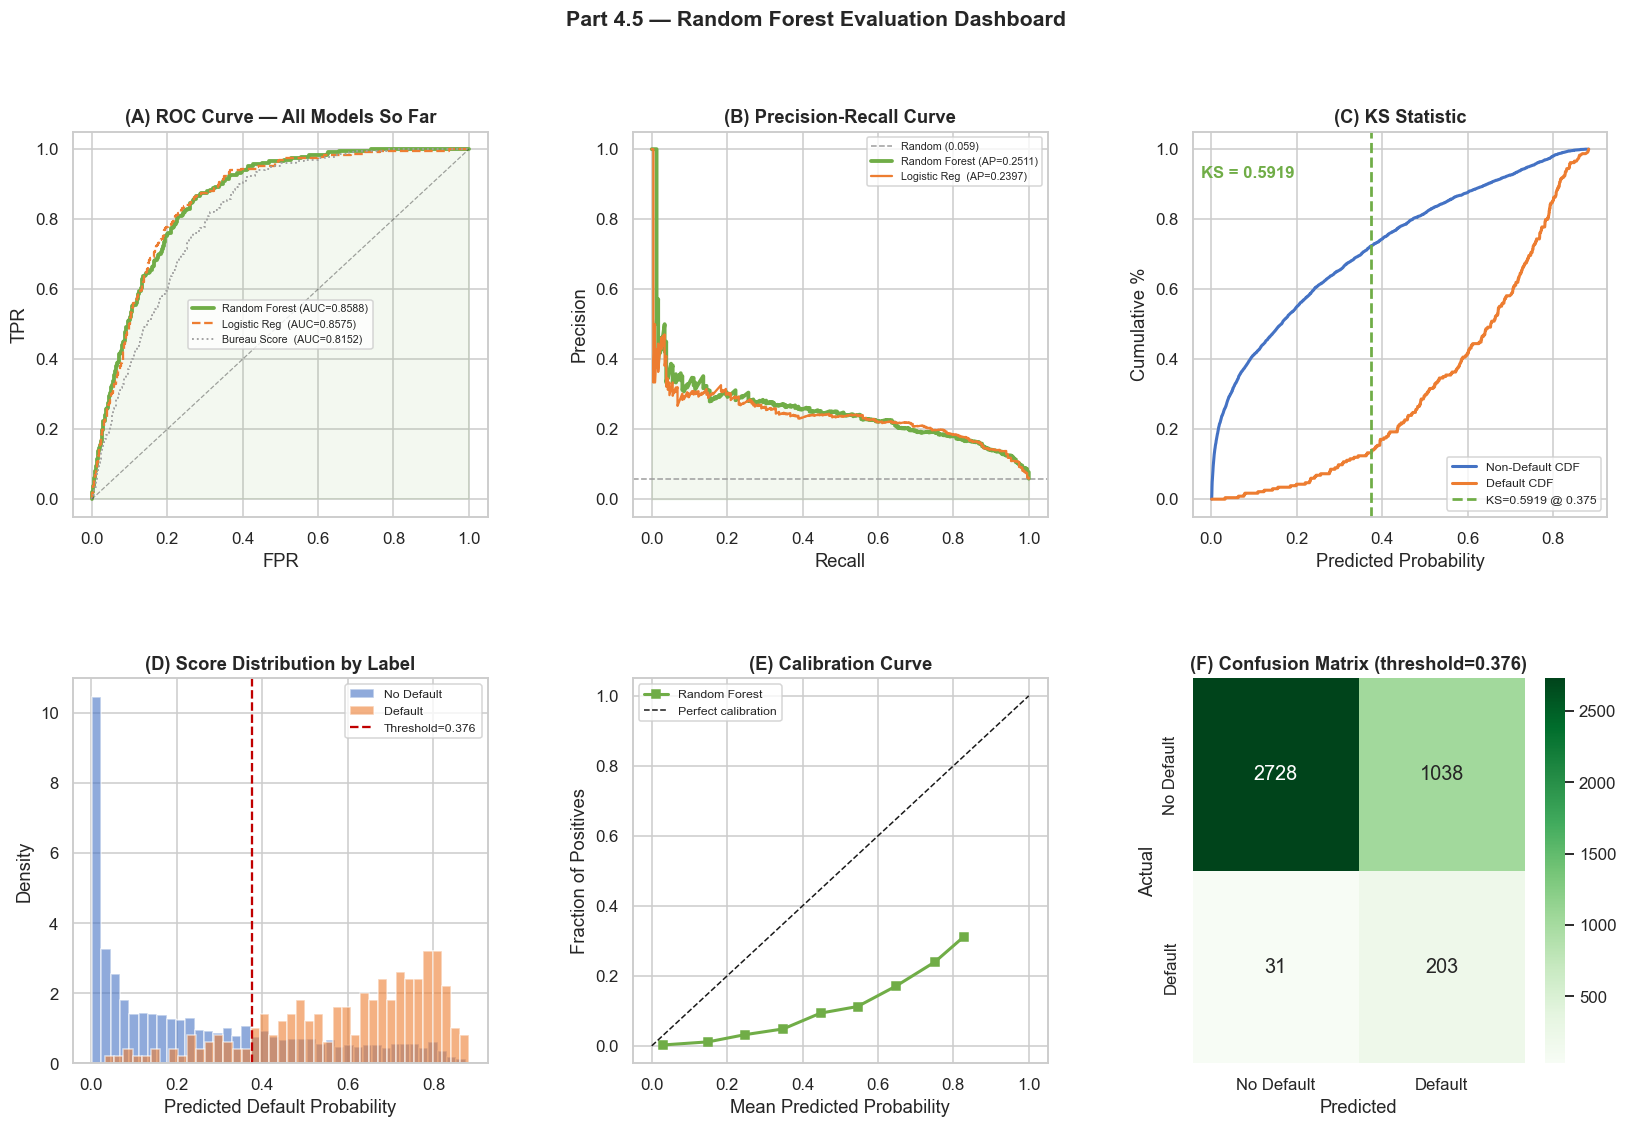

In [6]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Part 4.5 — Random Forest Evaluation Dashboard",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

lr_proba = results["Logistic Regression"]["proba_test"]

# (A) ROC — RF vs LR vs Bureau Score
ax = fig.add_subplot(gs[0, 0])
for proba, label, color, lw, ls in [
    (proba_test,  f"Random Forest (AUC={test_auc:.4f})", MODEL_COLOR, 2.5, "-"),
    (lr_proba,    f"Logistic Reg  (AUC={lr_auc:.4f})",   ORANGE,      1.5, "--"),
    (bureau_proba,f"Bureau Score  (AUC={bureau_auc:.4f})",GRAY,        1.2, ":"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls, label=label)
ax.fill_between(*roc_curve(y_test, proba_test)[:2], alpha=0.08, color=MODEL_COLOR)
ax.plot([0,1],[0,1], "k--", lw=0.8, alpha=0.4)
ax.set_title("(A) ROC Curve — All Models So Far", fontweight="bold")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=7)

# (B) PR Curve
ax = fig.add_subplot(gs[0, 1])
baseline = y_test.mean()
ax.axhline(baseline, color=GRAY, linestyle="--", lw=1, label=f"Random ({baseline:.3f})")
for proba, label, color, lw in [
    (proba_test,  f"Random Forest (AP={test_ap:.4f})",              MODEL_COLOR, 2.5),
    (lr_proba,    f"Logistic Reg  (AP={results['Logistic Regression']['test_ap']:.4f})", ORANGE, 1.5),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, color=color, lw=lw, label=label)
ax.fill_between(*precision_recall_curve(y_test, proba_test)[:2][::-1],
                alpha=0.08, color=MODEL_COLOR)
ax.set_title("(B) Precision-Recall Curve", fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=7)

# (C) KS Plot
ax = fig.add_subplot(gs[0, 2])
ax.plot(ks_df["p"], ks_df["cum_neg"], color=BLUE,   lw=2, label="Non-Default CDF")
ax.plot(ks_df["p"], ks_df["cum_pos"], color=ORANGE, lw=2, label="Default CDF")
ax.axvline(ks_thresh, color=GREEN, linestyle="--", lw=1.8,
           label=f"KS={ks_val:.4f} @ {ks_thresh:.3f}")
ax.set_title("(C) KS Statistic", fontweight="bold")
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Cumulative %")
ax.legend(fontsize=8)
ax.text(0.02, 0.88, f"KS = {ks_val:.4f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color=GREEN)

# (D) Score distribution
ax = fig.add_subplot(gs[1, 0])
for lbl, c, nm in [(0, BLUE, "No Default"), (1, ORANGE, "Default")]:
    ax.hist(proba_test[y_test==lbl], bins=40, alpha=0.60,
            color=c, density=True, label=nm)
ax.axvline(opt_thresh, color=RED, linestyle="--", lw=1.5,
           label=f"Threshold={opt_thresh:.3f}")
ax.set_title("(D) Score Distribution by Label", fontweight="bold")
ax.set_xlabel("Predicted Default Probability"); ax.set_ylabel("Density")
ax.legend(fontsize=8)

# (E) Calibration
ax = fig.add_subplot(gs[1, 1])
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
ax.plot(prob_pred, prob_true, "s-", color=MODEL_COLOR, lw=2,
        label="Random Forest", markersize=5)
ax.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
ax.set_title("(E) Calibration Curve", fontweight="bold")
ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
ax.legend(fontsize=8)

# (F) Confusion Matrix
ax = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"],
            annot_kws={"size": 13})
ax.set_title(f"(F) Confusion Matrix (threshold={opt_thresh:.3f})", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

---
## 8 — Feature Importance Analysis

Random Forest provides **Gini impurity-based feature importances** —  
how much each feature reduces impurity across all trees.

> **Note:** RF importances favour high-cardinality features. They show  
> *which features were used* most, not necessarily *which matter most causally*.  
> We will complement this with permutation importance for robustness.

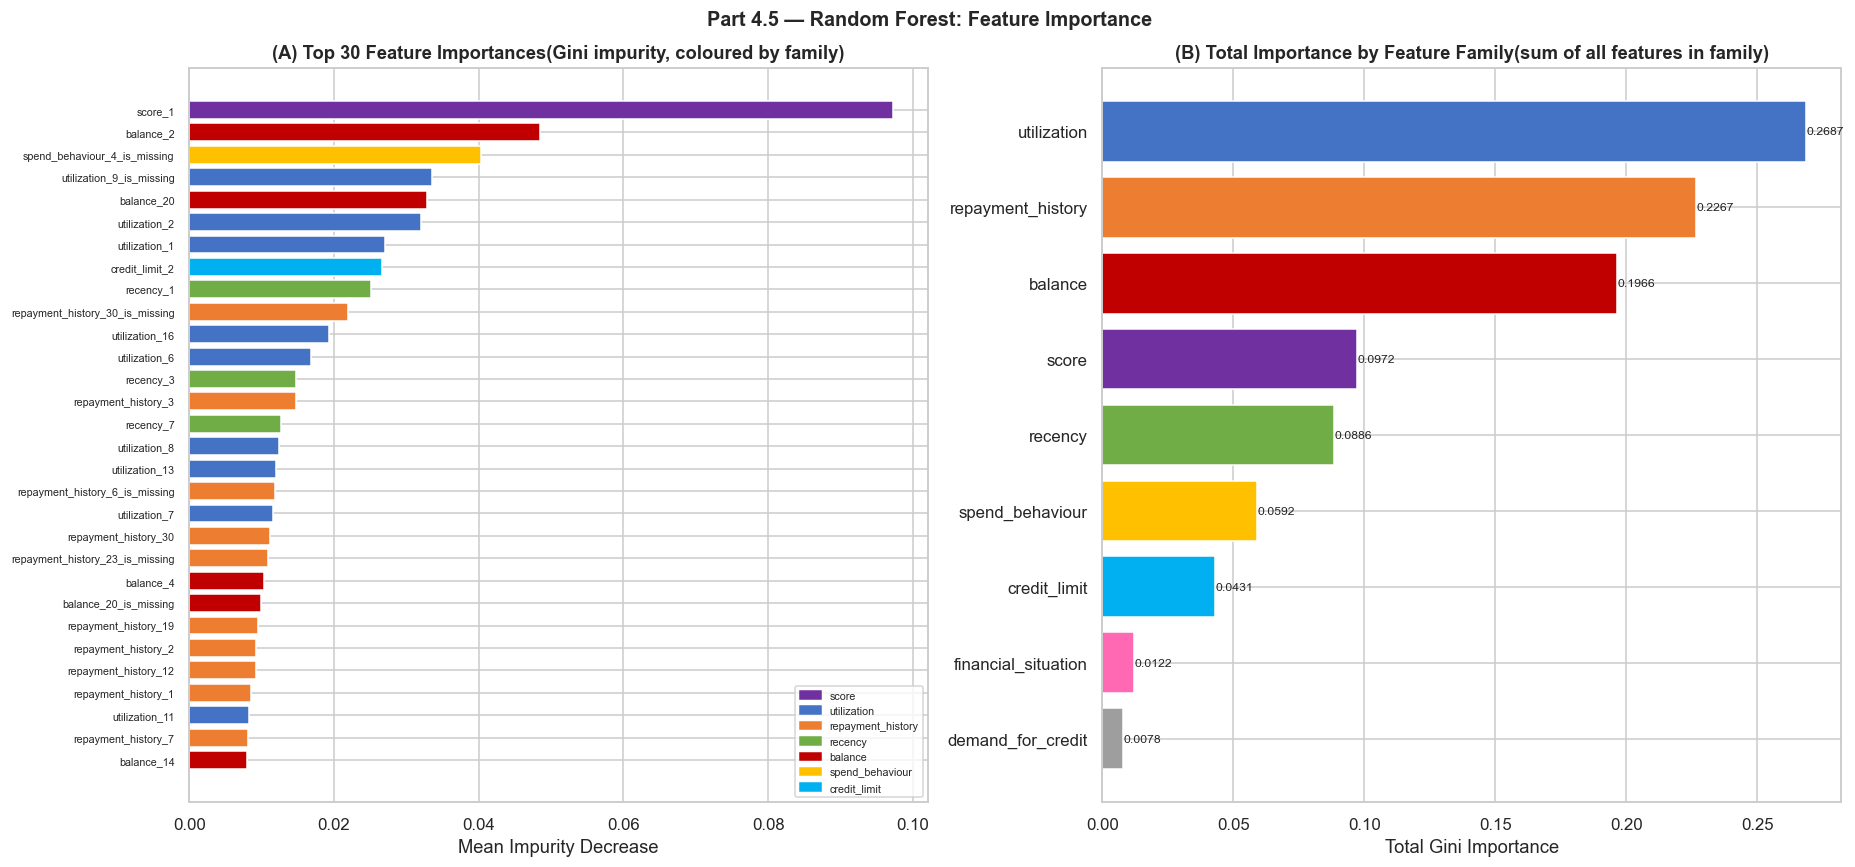

Top 15 most important features:
score_1                            0.097229
balance_2                          0.048489
spend_behaviour_4_is_missing       0.040324
utilization_9_is_missing           0.033571
balance_20                         0.032835
utilization_2                      0.032092
utilization_1                      0.027022
credit_limit_2                     0.026625
recency_1                          0.025167
repayment_history_30_is_missing    0.022015
utilization_16                     0.019323
utilization_6                      0.016811
recency_3                          0.014788
repayment_history_3                0.014757
recency_7                          0.012716


In [7]:
fi = pd.Series(rf.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)
top30 = fi_sorted.head(30)

# Tag feature families
import re
def get_family(col):
    m = re.match(r"^([a-z_]+?)_\d+", col)
    return m.group(1) if m else "other"

fam_color_map = {
    "score": PURPLE, "utilization": BLUE, "repayment_history": ORANGE,
    "recency": GREEN, "balance": RED, "spend_behaviour": "#FFC000",
    "credit_limit": "#00B0F0", "financial_situation": "#FF69B4",
    "demand_for_credit": GRAY
}

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle("Part 4.5 — Random Forest: Feature Importance",
             fontsize=13, fontweight="bold")

# (A) Top 30 features — coloured by family
ax = axes[0]
top30_sorted = top30.sort_values()
bar_colors   = [fam_color_map.get(get_family(f), GRAY) for f in top30_sorted.index]
ax.barh(top30_sorted.index, top30_sorted.values,
        color=bar_colors, edgecolor="white")
ax.set_title("(A) Top 30 Feature Importances(Gini impurity, coloured by family)",
             fontweight="bold")
ax.set_xlabel("Mean Impurity Decrease")
ax.tick_params(axis="y", labelsize=7)
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=f)
                  for f, c in fam_color_map.items()
                  if f in [get_family(ff) for ff in top30_sorted.index]]
ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

# (B) Importance by family (summed)
ax = axes[1]
fi_df = pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
fi_df["family"] = fi_df["feature"].apply(get_family)
fam_total = fi_df.groupby("family")["importance"].sum().sort_values(ascending=True)
bar_colors_fam = [fam_color_map.get(f, GRAY) for f in fam_total.index]
ax.barh(fam_total.index, fam_total.values,
        color=bar_colors_fam, edgecolor="white")
ax.set_title("(B) Total Importance by Feature Family(sum of all features in family)",
             fontweight="bold")
ax.set_xlabel("Total Gini Importance")
for i, (fam, val) in enumerate(fam_total.items()):
    ax.text(val + 0.0002, i, f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("Top 15 most important features:")
print(fi_sorted.head(15).round(6).to_string())

## 9 — OOB Score & CV Stability

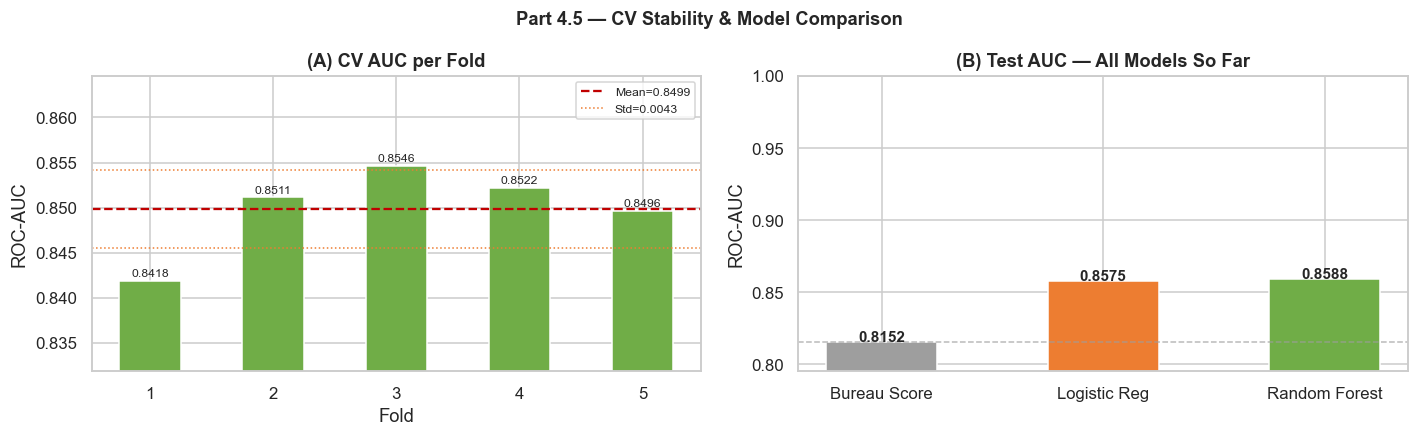

Overfit gap (train AUC - CV mean): +0.0762
  < 0.02 = healthy  |  0.02-0.05 = mild  |  > 0.05 = overfit

OOB score (accuracy proxy): 0.8069
Note: OOB uses accuracy not AUC — interpret directionally only


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Part 4.5 — CV Stability & Model Comparison", fontsize=12, fontweight="bold")

# (A) CV AUC per fold
ax = axes[0]
ax.bar(range(1, 6), cv_scores, color=MODEL_COLOR, edgecolor="white", width=0.5)
ax.axhline(cv_scores.mean(), color=RED, linestyle="--", lw=1.5,
           label=f"Mean={cv_scores.mean():.4f}")
ax.axhline(cv_scores.mean() - cv_scores.std(), color=ORANGE, linestyle=":", lw=1)
ax.axhline(cv_scores.mean() + cv_scores.std(), color=ORANGE, linestyle=":", lw=1,
           label=f"Std={cv_scores.std():.4f}")
ax.set_title("(A) CV AUC per Fold", fontweight="bold")
ax.set_xlabel("Fold"); ax.set_ylabel("ROC-AUC")
ax.set_xticks(range(1, 6))
ax.set_ylim(cv_scores.min() - 0.01, cv_scores.max() + 0.01)
ax.legend(fontsize=8)
for i, s in enumerate(cv_scores, 1):
    ax.text(i, s + 0.0005, f"{s:.4f}", ha="center", fontsize=8)

# (B) All models AUC comparison so far
ax = axes[1]
model_names  = ["Bureau Score", "Logistic Reg", "Random Forest"]
model_aucs   = [bureau_auc, lr_auc, test_auc]
model_colors = [GRAY, ORANGE, MODEL_COLOR]
bars = ax.bar(model_names, model_aucs, color=model_colors, edgecolor="white", width=0.5)
ax.set_ylim(min(model_aucs) - 0.02, 1.0)
ax.set_title("(B) Test AUC — All Models So Far", fontweight="bold")
ax.set_ylabel("ROC-AUC")
ax.axhline(bureau_auc, color=GRAY, linestyle="--", lw=1, alpha=0.7)
for bar, val in zip(bars, model_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Overfit gap (train AUC - CV mean): {train_auc - cv_scores.mean():+.4f}")
print(f"  < 0.02 = healthy  |  0.02-0.05 = mild  |  > 0.05 = overfit")
print()
print(f"OOB score (accuracy proxy): {rf.oob_score_:.4f}")
print("Note: OOB uses accuracy not AUC — interpret directionally only")

## 10 — Store Result & Save

In [9]:
rf_result = {
    "name"       : MODEL_NAME,
    "color"      : MODEL_COLOR,
    "model"      : rf,
    "proba_test" : proba_test,
    "test_auc"   : round(test_auc,         4),
    "test_ap"    : round(test_ap,          4),
    "gini"       : round(gini,             4),
    "ks"         : round(ks_val,           4),
    "ks_thresh"  : round(ks_thresh,        4),
    "ks_df"      : ks_df,
    "opt_thresh" : round(opt_thresh,       4),
    "y_pred_opt" : y_pred_opt,
    "cv_mean"    : round(cv_scores.mean(), 4),
    "cv_std"     : round(cv_scores.std(),  4),
    "cv_scores"  : cv_scores.tolist(),
    "train_auc"  : round(train_auc,        4),
    "train_time" : round(train_time,       1),
    "oob_score"  : round(rf.oob_score_,   4),
}

results[MODEL_NAME] = rf_result
joblib.dump(results, "results_so_far.pkl")
joblib.dump(rf,      "model_rf.pkl")

print("Saved:")
print("  results_so_far.pkl  (bureau + LR + RF)")
print("  model_rf.pkl")
print()
print("Result summary:")
for k in ["test_auc","test_ap","gini","ks","cv_mean","cv_std","train_auc","train_time"]:
    print(f"  {k:<18}: {rf_result[k]}")

Saved:
  results_so_far.pkl  (bureau + LR + RF)
  model_rf.pkl

Result summary:
  test_auc          : 0.8588
  test_ap           : 0.2511
  gini              : 0.7177
  ks                : 0.5919
  cv_mean           : 0.8499
  cv_std            : 0.0043
  train_auc         : 0.9261
  train_time        : 9.2


---
## Summary

### Random Forest Results

| Metric | Value |
|---|---|
| **Test ROC-AUC** | see output |
| **Test Avg Precision** | see output |
| **Gini Coefficient** | see output |
| **KS Statistic** | see output |
| **CV AUC (mean ± std)** | see output |
| **OOB Score** | see output |

### Key observations

**Strengths vs Logistic Regression:**
- Captures non-linear relationships between features and default risk
- No feature scaling required — trees split on rank order
- OOB score gives a free internal validation estimate
- Feature importances reveal which feature families drive predictions

**Potential weaknesses:**
- Predicted probabilities tend to cluster near the centre (0.3–0.7)  
  — less separation than GBM (check calibration curve)
- Still slower than LR to train and score
- Feature importances can be misleading for correlated features

**What Gradient Boosting (Part 4.6) adds:**
- Sequential learning — each tree corrects the previous tree's errors
- Typically achieves higher AUC on structured tabular data
- More tunable via learning rate and subsampling

---
**Next → Part 4.6: Gradient Boosting Machine**